# Network Incident Loss Payload Predictor

Model regresi untuk memprediksi `loss_payload` (volume traffic yang hilang saat insiden jaringan).

Penggunaan: post-incident analysis. Seluruh data insiden diasumsikan sudah lengkap saat prediksi dijalankan, termasuk `baseline_payload`. Model ini ditujukan untuk pelaporan dan audit loss otomatis, bukan prediksi real-time.

Dokumen ini menyertakan justifikasi untuk setiap keputusan preprocessing dan feature engineering pada sel markdown sebelum kodenya.

### 1. Import Library
Menyiapkan seluruh library yang dipakai sepanjang pipeline: manipulasi data
(`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`), machine learning
(`scikit-learn`, `xgboost`), dan penyimpanan model (`joblib`).

In [32]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

### 2.Konfigurasi Awal
mendefinisikan konstanta global (nama file input, nama kolom target,
folder output, random seed) yang dipakai berulang kali di bawah — supaya kalau nama file
atau target berubah, cukup diubah di satu tempat.

`RANDOM_STATE = 42` dipakai konsisten di semua split & model agar hasil bisa
direproduksi.

In [33]:
FILE_MAIN = "inap_ticketing_incident_loss_payload_2026.xlsx"
FILE_HOURLY = "baseline_payload_hourly_weekly.csv"
TARGET = "loss_payload"
OUTPUT_DIR = "output_ml_new"
RANDOM_STATE = 42

SEV_MAP = {"low": 1, "minor": 2, "major": 3, "critical": 4}

FEATURES_FINAL = [
    "severity_num", "durasi_menit", "baseline_payload", "payload", "rpmb",
    "availability_full", "update_impact", "impacted_sites_count", "hour",
    "month", "is_peak_hour", "regional", "day_type",
    "rootcausecategory", "log_baseline_payload", "log_payload",
    "log_rpmb", "durasi_x_severity", "hourly_baseline",
]

CAT_COLS = ["site_id", "regional", "day_type", "rootcausecategory"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Konfigurasi siap. Folder output:", OUTPUT_DIR)

Konfigurasi siap. Folder output: output_ml_new


### 3. Helper Functions
fungsi pembersih data yang dipakai berkali-kali di seluruh pipeline,
jadi dipisah supaya tidak duplikasi logika

 `to_numeric_safe`: mengubah kolom string dengan format desimal koma (mis. `"12,5"`) jadi
angka float; nilai yang gagal dikonversi jadi `NaN` (bukan error).
`duration_to_minutes`: mengubah string durasi format `HH:MM:SS` jadi total menit (float).
`count_impacted_sites`: menghitung jumlah site yang terdampak dari kolom `url` yang
berisi banyak URL dipisah `;`; kosong/NaN dianggap 1 site.

Fungsi-Fungsi ini "aman terhadap error" (pakai `try/except` atau `errors="coerce"`)
supaya baris data kotor tidak menghentikan seluruh proses.

In [34]:
def to_numeric_safe(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


def duration_to_minutes(value):
    try:
        h, m, s = str(value).strip().split(":")
        return int(h) * 60 + int(m) + float(s) / 60
    except Exception:
        return np.nan


def count_impacted_sites(url_value):
    if pd.isna(url_value) or str(url_value).strip() == "":
        return 1
    return len(str(url_value).split(";"))

### 4. Data Collection

##### 4.1 Load data
Membaca dua sumber data: data insiden utama (`.xlsx`, dibaca sebagai string
semua kolom via `dtype=str` supaya format asli seperti koma desimal tidak rusak saat load)
dan data baseline payload per jam (`.csv`).

**Fungsi:** `df_hourly` nantinya jadi tabel referensi untuk mencari "payload normal" pada
jam & hari tertentu di site tertentu, dipakai sebagai fitur pembanding terhadap payload insiden.

In [35]:
df_raw = pd.read_excel(FILE_MAIN, dtype=str)
df_hourly = pd.read_csv(FILE_HOURLY)

print("Shape Data Utama  :", df_raw.shape)
print("Shape Data Hourly :", df_hourly.shape)
print("Kolom Data Utama  :", list(df_raw.columns))

Shape Data Utama  : (81033, 19)
Shape Data Hourly : (822965, 7)
Kolom Data Utama  : ['site_id', 'ticket_id', 'severity', 'alarm_start_time', 'alarm_clear_time', 'duarasi_alaram', 'payload', 'baseline_payload', 'loss_payload', 'rpmb', 'availability_full', 'regional', 'day_type', 'rootcausecategory', 'rootcausedetail', 'order_status', 'sitetype', 'update_impact', 'url']


### 5. EDA (Exploratory Data Analysis) - Audit Data Mentah

#### 5.1 Cek Missing Value

Untuk Mengecek dan menampilkan jumlah serta persentase nilai
kosong (missing value/NaN) pada setiap kolom, untuk kedua
sumber data (data utama & data hourly).

In [36]:
missing_raw = df_raw.isnull().sum()
missing_raw_pct = (missing_raw / len(df_raw) * 100).round(1)
table_raw = pd.DataFrame({"missing": missing_raw, "pct": missing_raw_pct})

print("--- Missing Value: Data Utama (Incident) ---")
if missing_raw.sum() > 0:
    print(table_raw[table_raw["missing"] > 0].to_string())
else:
    print("Tidak ada missing value pada data utama.")
print()

missing_hourly = df_hourly.isnull().sum()
missing_hourly_pct = (missing_hourly / len(df_hourly) * 100).round(1)
table_hourly = pd.DataFrame({"missing": missing_hourly, "pct": missing_hourly_pct})

print("--- Missing Value: Data Hourly Baseline ---")
if missing_hourly.sum() > 0:
    print(table_hourly[table_hourly["missing"] > 0].to_string())
else:
    print("Tidak ada missing value pada data hourly baseline.")

--- Missing Value: Data Utama (Incident) ---
                   missing   pct
payload                 51   0.1
baseline_payload     54440  67.2
loss_payload         54440  67.2
rpmb                   479   0.6
availability_full      577   0.7
rootcausedetail          1   0.0

--- Missing Value: Data Hourly Baseline ---
                 missing    pct
yearweek          822965  100.0
avg_traffic_erl        1    0.0


#### 5.2 CEK KONSISTENSI TARGET vs BASELINE_PAYLOAD
Mengecek konsistensi antara kolom target (`loss_payload`) dan kolom
`baseline_payload` setelah keduanya dipaksa jadi numerik: berapa baris
NaN di keduanya sekaligus, dan berapa baris NaN hanya di salah satu
(menandakan kemungkinan anomali di sumber data). Kedua kolom ini krusial
karena target adalah yang mau diprediksi, dan baseline_payload adalah fitur utama.

In [37]:
loss_na = to_numeric_safe(df_raw[TARGET]).isna()
base_na = to_numeric_safe(df_raw["baseline_payload"]).isna()

print("loss_payload NaN         :", loss_na.sum())
print("baseline_payload NaN     :", base_na.sum())
print("Keduanya NaN bersamaan   :", (loss_na & base_na).sum())
print("Hanya salah satu NaN     :", (loss_na ^ base_na).sum())

loss_payload NaN         : 54440
baseline_payload NaN     : 54440
Keduanya NaN bersamaan   : 54440
Hanya salah satu NaN     : 0


### 6. Preprocessing

Pada tahap ini murni pembersihan data mentah (teks, tanggal, durasi) menjadi bentuk yang valid/konsisten

In [38]:
df_eda = df_raw.copy()

#### 6.1 Target & kolom numerik dasar
target diubah ke numerik, baris tanpa
target dibuang (tidak bisa dipakai supervised learning). Kolom
numerik lain (payload, baseline_payload, rpmb, availability_full,
update_impact) juga diubah ke numerik.

In [39]:
df_eda[TARGET] = to_numeric_safe(df_eda[TARGET])
baris_sebelum = len(df_eda)
df_eda = df_eda[df_eda[TARGET].notna()].copy()
print(f"Baris sebelum buang target kosong : {baris_sebelum}")
print(f"Baris setelah buang target kosong : {len(df_eda)} "
      f"(terbuang: {baris_sebelum - len(df_eda)})")

for col in ["payload", "baseline_payload", "rpmb", "availability_full", "update_impact"]:
    df_eda[col] = to_numeric_safe(df_eda[col])

Baris sebelum buang target kosong : 81033
Baris setelah buang target kosong : 26593 (terbuang: 54440)


#### 6.2 Fitur waktu
hour, month, day_name_type (weekday/weekend), is_peak_hour (1 jika jam 08:00-22:00).

In [40]:
alarm_dt = pd.to_datetime(df_eda["alarm_start_time"], errors="coerce")
df_eda["hour"] = alarm_dt.dt.hour.fillna(0).astype(int)
df_eda["month"] = alarm_dt.dt.month
df_eda["day_name_type"] = alarm_dt.dt.dayofweek.apply(lambda x: "weekend" if x >= 5 else "weekday")
df_eda["is_peak_hour"] = df_eda["hour"].between(8, 22).astype(int)
print("Fitur waktu dibuat: hour, month, day_name_type, is_peak_hour")

Fitur waktu dibuat: hour, month, day_name_type, is_peak_hour


#### 6.3 Durasi insiden
durasi_menit dari teks "HH:MM:SS".

In [41]:
df_eda["durasi_menit"] = df_eda["duarasi_alaram"].apply(duration_to_minutes)
print(f"Fitur durasi_menit -> min={df_eda['durasi_menit'].min():.1f}, "
      f"median={df_eda['durasi_menit'].median():.1f}, "
      f"max={df_eda['durasi_menit'].max():.1f}")

Fitur durasi_menit -> min=0.5, median=107.8, max=1438.5


### 7. Feature Engineering

#### 7.1 Gabung dengan baseline per jam (left join site_id+hour+hari) 
agar jumlah baris tidak berubah; hasil dinamakan hourly_baseline.

In [42]:
# -- Gabung dengan baseline per jam (left join, jumlah baris tidak berubah) --
df_eda = df_eda.merge(
    df_hourly[["site_id", "hour", "day_name", "avg_payload_gb"]],
    left_on=["site_id", "hour", "day_name_type"],
    right_on=["site_id", "hour", "day_name"],
    how="left",
)
df_eda.rename(columns={"avg_payload_gb": "hourly_baseline"}, inplace=True)
df_eda["hourly_baseline"] = pd.to_numeric(df_eda["hourly_baseline"]).fillna(0)
print(f"Baris valid setelah integrasi dengan baseline hourly: {len(df_eda)}")

Baris valid setelah integrasi dengan baseline hourly: 26593


#### 7.2 Fitur turunan lain
 impacted_sites_count, transformasi log1p
(log_baseline_payload, log_payload, log_rpmb), severity_num, dan
fitur interaksi durasi_x_severity (durasi lama + 
severity tinggi biasanya lebih merusak).

In [43]:
# -- Fitur turunan lain --
df_eda["impacted_sites_count"] = df_eda["url"].apply(count_impacted_sites)
df_eda["log_baseline_payload"] = np.log1p(df_eda["baseline_payload"])
df_eda["log_payload"] = np.log1p(df_eda["payload"])
df_eda["log_rpmb"] = np.log1p(df_eda["rpmb"])
df_eda["severity_num"] = df_eda["severity"].str.lower().map(SEV_MAP)
df_eda["durasi_x_severity"] = df_eda["durasi_menit"] * df_eda["severity_num"]
print("Fitur turunan dibuat: impacted_sites_count, log_baseline_payload, "
      "log_payload, log_rpmb, severity_num, durasi_x_severity")
print(f"Total kolom pada df_eda setelah feature engineering: {df_eda.shape[1]}")

Fitur turunan dibuat: impacted_sites_count, log_baseline_payload, log_payload, log_rpmb, severity_num, durasi_x_severity
Total kolom pada df_eda setelah feature engineering: 32


### 8. EDA (Exploratory Data Analysis) - Setelah Preprocessing dan Feature Engineering

#### 8.1 EDA - Distribusi Target
Membuat & menyimpan grafik distribusi loss_payload dalam dua versi: 
skala asli dan skala log1p. Data loss_payload biasanya sangat "miring"
(skewed) — banyak insiden kecil, sedikit insiden ekstrem besar. Grafik
ini membuktikan secara visual kenapa model nanti dilatih pada skala log,
bukan skala asli.

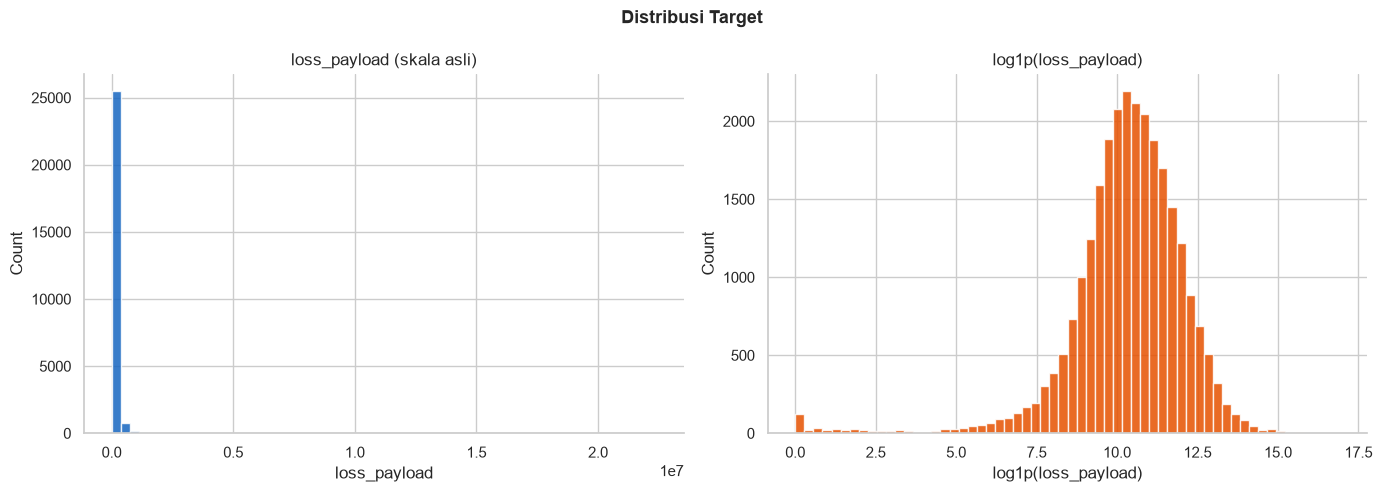

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Target", fontsize=13, fontweight="bold")

axes[0].hist(df_eda[TARGET].dropna(), bins=60, color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].set_title("loss_payload (skala asli)")
axes[0].set_xlabel("loss_payload")
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(np.log1p(df_eda[TARGET].dropna()), bins=60, color="#E65100", edgecolor="white", alpha=0.85)
axes[1].set_title("log1p(loss_payload)")
axes[1].set_xlabel("log1p(loss_payload)")
axes[1].set_ylabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
eda_plot_path = f"{OUTPUT_DIR}/eda_target_distribution.png"
plt.savefig(eda_plot_path, dpi=150, bbox_inches="tight")
plt.show()

In [45]:
print("Statistik ringkas loss_payload (skala asli):")
print(df_eda[TARGET].describe().round(2).to_string())
print(f"Grafik distribusi target disimpan di: {eda_plot_path}")

Statistik ringkas loss_payload (skala asli):
count       26593.00
mean        92404.13
std        286977.54
min             0.00
25%         13540.46
50%         34234.48
75%         88108.39
max      22398765.01
Grafik distribusi target disimpan di: output_ml_new/eda_target_distribution.png


#### 8.2 EDA - Tabel Korelasi
Menghitung korelasi (Pearson) antara fitur numerik utama dengan target,
baik skala asli maupun skala log target. Membantu memahami fitur mana
yang paling berhubungan linear dengan target, sekaligus jadi bukti
tambahan bahwa fitur log lebih berkorelasi dengan log target.

In [46]:
num_cols = [
    "baseline_payload", "log_baseline_payload",
    "payload", "log_payload",
    "hourly_baseline", "rpmb", "availability_full",
    "update_impact", "durasi_menit",
]
log_target = np.log1p(df_eda[TARGET])

corr_raw = df_eda[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_log = df_eda[num_cols].assign(log_target=log_target).corr()["log_target"].drop("log_target")

corr_table = pd.DataFrame({
    "vs target asli": corr_raw,
    "vs log target": corr_log,
}).sort_values("vs log target", ascending=False)

print("Tabel Korelasi Fitur Numerik:")
print(corr_table.round(3).to_string())

Tabel Korelasi Fitur Numerik:
                      vs target asli  vs log target
log_baseline_payload           0.358          0.955
hourly_baseline                0.189          0.433
baseline_payload               0.992          0.429
log_payload                    0.102          0.410
payload                        0.395          0.279
update_impact                  0.067          0.021
availability_full             -0.148         -0.003
durasi_menit                   0.189         -0.009
rpmb                          -0.007         -0.079


### 9. Preprocessing Lanjutan 

#### 9.1 Encoding Kolom Kategorikal
Meng-encode kolom kategorikal (site_id, regional, day_type,
rootcausecategory) menjadi angka via LabelEncoder, karena model ML
butuh input numerik. Nilai kosong diisi "unknown" dulu sebelum
di-encode, supaya nanti saat inference ada kategori fallback untuk
data baru yang belum pernah dilihat model. `encoders` disimpan supaya
bisa dipakai ulang persis di tahap inference nanti.

In [47]:
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_eda[col] = df_eda[col].fillna("unknown").astype(str)
    df_eda[col] = le.fit_transform(df_eda[col])
    encoders[col] = le
    print(f"Kolom '{col}' di-encode -> {len(le.classes_)} kategori unik")

Kolom 'site_id' di-encode -> 8501 kategori unik
Kolom 'regional' di-encode -> 3 kategori unik
Kolom 'day_type' di-encode -> 2 kategori unik
Kolom 'rootcausecategory' di-encode -> 6 kategori unik


### 10. Model Training

#### 10.1 SPLIT DATA (TRAIN/TEST)

In [48]:
df_model = df_eda[FEATURES_FINAL + [TARGET]].dropna()
X = df_model[FEATURES_FINAL]
y_raw = df_model[TARGET]
y_log = np.log1p(y_raw)

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Total data untuk modeling (setelah dropna) : {len(df_model)}")
print(f"Jumlah fitur yang dipakai                   : {len(FEATURES_FINAL)}")
print(f"Data training                                : {X_train.shape[0]} baris")
print(f"Data testing                                 : {X_test.shape[0]} baris")

Total data untuk modeling (setelah dropna) : 25684
Jumlah fitur yang dipakai                   : 19
Data training                                : 20547 baris
Data testing                                 : 5137 baris


#### 10.2 TRAINING RANDOM FOREST
Melatih SATU model Random Forest Regressor pada data training, dengan
target skala log (y_train_log). Skala log dipakai karena loss_payload
sangat skewed (lihat EDA) -- model tree-based lebih stabil belajar pada
skala log dibanding skala asli yang rentangnya sangat lebar.
Hyperparameter: 500 pohon (n_estimators), kedalaman tidak dibatasi
(max_depth=None), memakai semua core CPU (n_jobs=-1).

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
print("Melatih model Random Forest... Mohon tunggu.")
rf_model.fit(X_train, y_train_log)

Melatih model Random Forest... Mohon tunggu.


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### 10.3 EXPORT TRAINING & TEST SET
Menyimpan data training & testing (fitur + target skala asli) sebagai
CSV terpisah, untuk keperluan audit/dokumentasi di luar pipeline

In [50]:
df_train_export = X_train.copy()
df_train_export[TARGET] = y_train_raw.values
train_set_path = f"{OUTPUT_DIR}/training_set.csv"
df_train_export.to_csv(train_set_path, index=True)

df_test_export = X_test.copy()
df_test_export[TARGET] = y_test_raw.values
test_set_path = f"{OUTPUT_DIR}/test_set.csv"
df_test_export.to_csv(test_set_path, index=True)

print(f"Training set disimpan di : {train_set_path} ({len(df_train_export)} baris)")
print(f"Test set disimpan di     : {test_set_path} ({len(df_test_export)} baris)")

Training set disimpan di : output_ml_new/training_set.csv (20547 baris)
Test set disimpan di     : output_ml_new/test_set.csv (5137 baris)


#### 10.4 TUNING XGBOOST
Mencari kombinasi hyperparameter terbaik untuk XGBRegressor memakai
RandomizedSearchCV (mencoba 20 kombinasi acak dari ruang pencarian, tiap
kombinasi dievaluasi dengan 5-fold cross-validation di dalam data
training, dinilai dari skor R2). Setelah ketemu kombinasi terbaik,
model final otomatis dilatih ulang pada seluruh X_train dengan
parameter tersebut.

In [51]:
param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 5, 6, 7],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
}
search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
print("Tuning XGBoost (skala log)...")
search.fit(X_train, y_train_log)
xgb_model = search.best_estimator_

print("Tuning selesai.")
print("Best params  :", search.best_params_)
print(f"Best CV R2 (di dalam training set) : {search.best_score_:.4f}")

Tuning XGBoost (skala log)...
Tuning selesai.
Best params  : {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV R2 (di dalam training set) : 0.9332


#### 10.5 CROSS-VALIDATION (SKALA LOG -> DIKEMBALIKAN KE ASLI)
Mengukur seberapa stabil performa tiap model di berbagai potongan data
berbeda (bukan cuma satu kali split train/test).

In [52]:
def hitung_cv_r2_skala_log(model, X_all, y_raw_all, y_log_all, cv=5, random_state=RANDOM_STATE):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    X_arr = X_all.reset_index(drop=True)
    y_raw_arr = y_raw_all.reset_index(drop=True)
    y_log_arr = y_log_all.reset_index(drop=True)

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr), start=1):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr.iloc[train_idx], y_log_arr.iloc[train_idx])
        pred_log = model_clone.predict(X_arr.iloc[val_idx])
        pred_raw = np.maximum(0, np.expm1(pred_log))
        fold_r2 = r2_score(y_raw_arr.iloc[val_idx], pred_raw)
        scores.append(fold_r2)
        print(f"  Fold {fold_idx}/{cv} -> R2 = {fold_r2:.4f}")

    return np.array(scores)


print("--- Cross-Validation XGBoost ---")
xgb_cv = hitung_cv_r2_skala_log(xgb_model, X, y_raw, y_log)
print(f"XGBoost CV R2: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")
print()

print("--- Cross-Validation Random Forest ---")
rf_cv = hitung_cv_r2_skala_log(rf_model, X, y_raw, y_log)
print(f"Random Forest CV R2: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

--- Cross-Validation XGBoost ---
  Fold 1/5 -> R2 = 0.9843
  Fold 2/5 -> R2 = 0.9797
  Fold 3/5 -> R2 = 0.9671
  Fold 4/5 -> R2 = 0.9673
  Fold 5/5 -> R2 = 0.9662
XGBoost CV R2: 0.9729 (+/- 0.0076)

--- Cross-Validation Random Forest ---
  Fold 1/5 -> R2 = 0.9888
  Fold 2/5 -> R2 = 0.9887
  Fold 3/5 -> R2 = 0.9882
  Fold 4/5 -> R2 = 0.9900
  Fold 5/5 -> R2 = 0.9901
Random Forest CV R2: 0.9892 (+/- 0.0007)


### 11. Evaluasi

#### 11.1. Evaluasi Test Set & Pemilihan Model Terbaik
Menghitung MAE, RMSE, R2 di skala asli untuk kedua model (prediksi
di-expm1 dari skala log, lalu di-clip minimal 0), lalu memilih model
dengan R2 tertinggi sebagai best_model. Jika Random Forest R2 >= XGBoost
R2, Random Forest dipilih (aturan tie-break berpihak ke Random Forest).

In [53]:
y_pred_xgb_log = xgb_model.predict(X_test)
y_pred_xgb = np.maximum(0, np.expm1(y_pred_xgb_log))
metrics_xgb = {
    "MAE": mean_absolute_error(y_test_raw, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb)),
    "R2": r2_score(y_test_raw, y_pred_xgb),
}
print(f"XGBoost      -> MAE={metrics_xgb['MAE']:,.2f}  RMSE={metrics_xgb['RMSE']:,.2f}  R2={metrics_xgb['R2']:.4f}")

y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf = np.maximum(0, np.expm1(y_pred_rf_log))
metrics_rf = {
    "MAE": mean_absolute_error(y_test_raw, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test_raw, y_pred_rf)),
    "R2": r2_score(y_test_raw, y_pred_rf),
}
print(f"Random Forest-> MAE={metrics_rf['MAE']:,.2f}  RMSE={metrics_rf['RMSE']:,.2f}  R2={metrics_rf['R2']:.4f}")

results_df = pd.DataFrame({"XGBoost": metrics_xgb, "Random Forest": metrics_rf}).T
print("\nPerbandingan Metrik Evaluasi (keduanya skala log -> expm1):")
print(results_df.round(4).to_string())

if metrics_rf["R2"] >= metrics_xgb["R2"]:
    best_model, best_model_name = rf_model, "Random Forest"
    best_preds, best_metrics = y_pred_rf, metrics_rf
else:
    best_model, best_model_name = xgb_model, "XGBoost"
    best_preds, best_metrics = y_pred_xgb, metrics_xgb

best_is_log_model = True 
print(f"Best Model: {best_model_name} (R2={best_metrics['R2']:.4f})")

XGBoost      -> MAE=7,228.33  RMSE=14,486.38  R2=0.9839
Random Forest-> MAE=6,128.08  RMSE=12,133.32  R2=0.9887

Perbandingan Metrik Evaluasi (keduanya skala log -> expm1):
                     MAE        RMSE      R2
XGBoost        7228.3319  14486.3794  0.9839
Random Forest  6128.0809  12133.3204  0.9887
Best Model: Random Forest (R2=0.9887)


#### 11.2 FEATURE IMPORTANCE MODEL TERBAIK
Mengambil skor feature_importances_ dari model terbaik (baik Random
Forest maupun XGBoost punya atribut ini), lalu mengurutkan dari yang
paling berpengaruh. Berguna untuk memahami fitur mana yang paling
banyak dipakai model saat membuat keputusan prediksi.

In [54]:
feat_imp = pd.DataFrame({
    "Feature": FEATURES_FINAL,
    "Importance": best_model.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(f"Best model: {best_model_name}")
print(f"R2={best_metrics['R2']:.4f}  MAE={best_metrics['MAE']:,.2f}  RMSE={best_metrics['RMSE']:,.2f}")
print("\nTop-10 Feature Importance:")
print(feat_imp.head(10).to_string(index=False))

Best model: Random Forest
R2=0.9887  MAE=6,128.08  RMSE=12,133.32

Top-10 Feature Importance:
             Feature  Importance
log_baseline_payload    0.466901
    baseline_payload    0.443291
        durasi_menit    0.037729
     hourly_baseline    0.015068
   durasi_x_severity    0.006712
                hour    0.005160
             payload    0.005138
         log_payload    0.005105
   availability_full    0.004848
            log_rpmb    0.002562


#### 11.3 ANALISIS ERROR PER KELOMPOK BESARAN NILAI
Satu angka MAE/R2 global bisa menyembunyikan fakta bahwa model sangat
akurat untuk insiden kecil tapi buruk untuk insiden besar (atau
sebaliknya). Di sini, error dipecah per kelompok besaran nilai aktual
(< 10k, 10k-100k, 100k-1jt, > 1jt) supaya kelihatan di mana model kuat
dan di mana model masih lemah.

In [55]:
eval_df = pd.DataFrame({"actual": y_test_raw.values, "predicted": best_preds})
eval_df["abs_error"] = (eval_df["actual"] - eval_df["predicted"]).abs()
eval_df["ape"] = eval_df["abs_error"] / (eval_df["actual"] + 1)

bins = [(0, 1e4, "< 10k"), (1e4, 1e5, "10k - 100k"), (1e5, 1e6, "100k - 1jt"), (1e6, np.inf, "> 1jt")]

print(f"{'Kelompok':<14}{'N':>7}{'MAE':>16}{'Median APE':>14}")
for lo, hi, label in bins:
    mask = (eval_df["actual"] >= lo) & (eval_df["actual"] < hi)
    if mask.sum() > 0:
        subset = eval_df[mask]
        mae_kelompok = subset["abs_error"].mean()
        ape_kelompok = subset["ape"].median() * 100
        print(f"{label:<14}{mask.sum():>7}{mae_kelompok:>16,.0f}{ape_kelompok:>13.1f}%")

Kelompok            N             MAE    Median APE
< 10k             951           2,446         24.1%
10k - 100k       3111           4,474          7.5%
100k - 1jt       1068          14,017          4.7%
> 1jt               7          37,814          2.4%


### 11.4  Visualisasi Evaluasi
Membuat satu dashboard visual (5 panel) merangkum evaluasi model
terbaik: Feature Importance, Actual vs Predicted (skala asli & log),
Residual Distribution, dan perbandingan Cross-Validation R2 antara
XGBoost vs Random Forest. Satu gambar ringkas ini memudahkan siapa pun
menilai kualitas model secara visual.

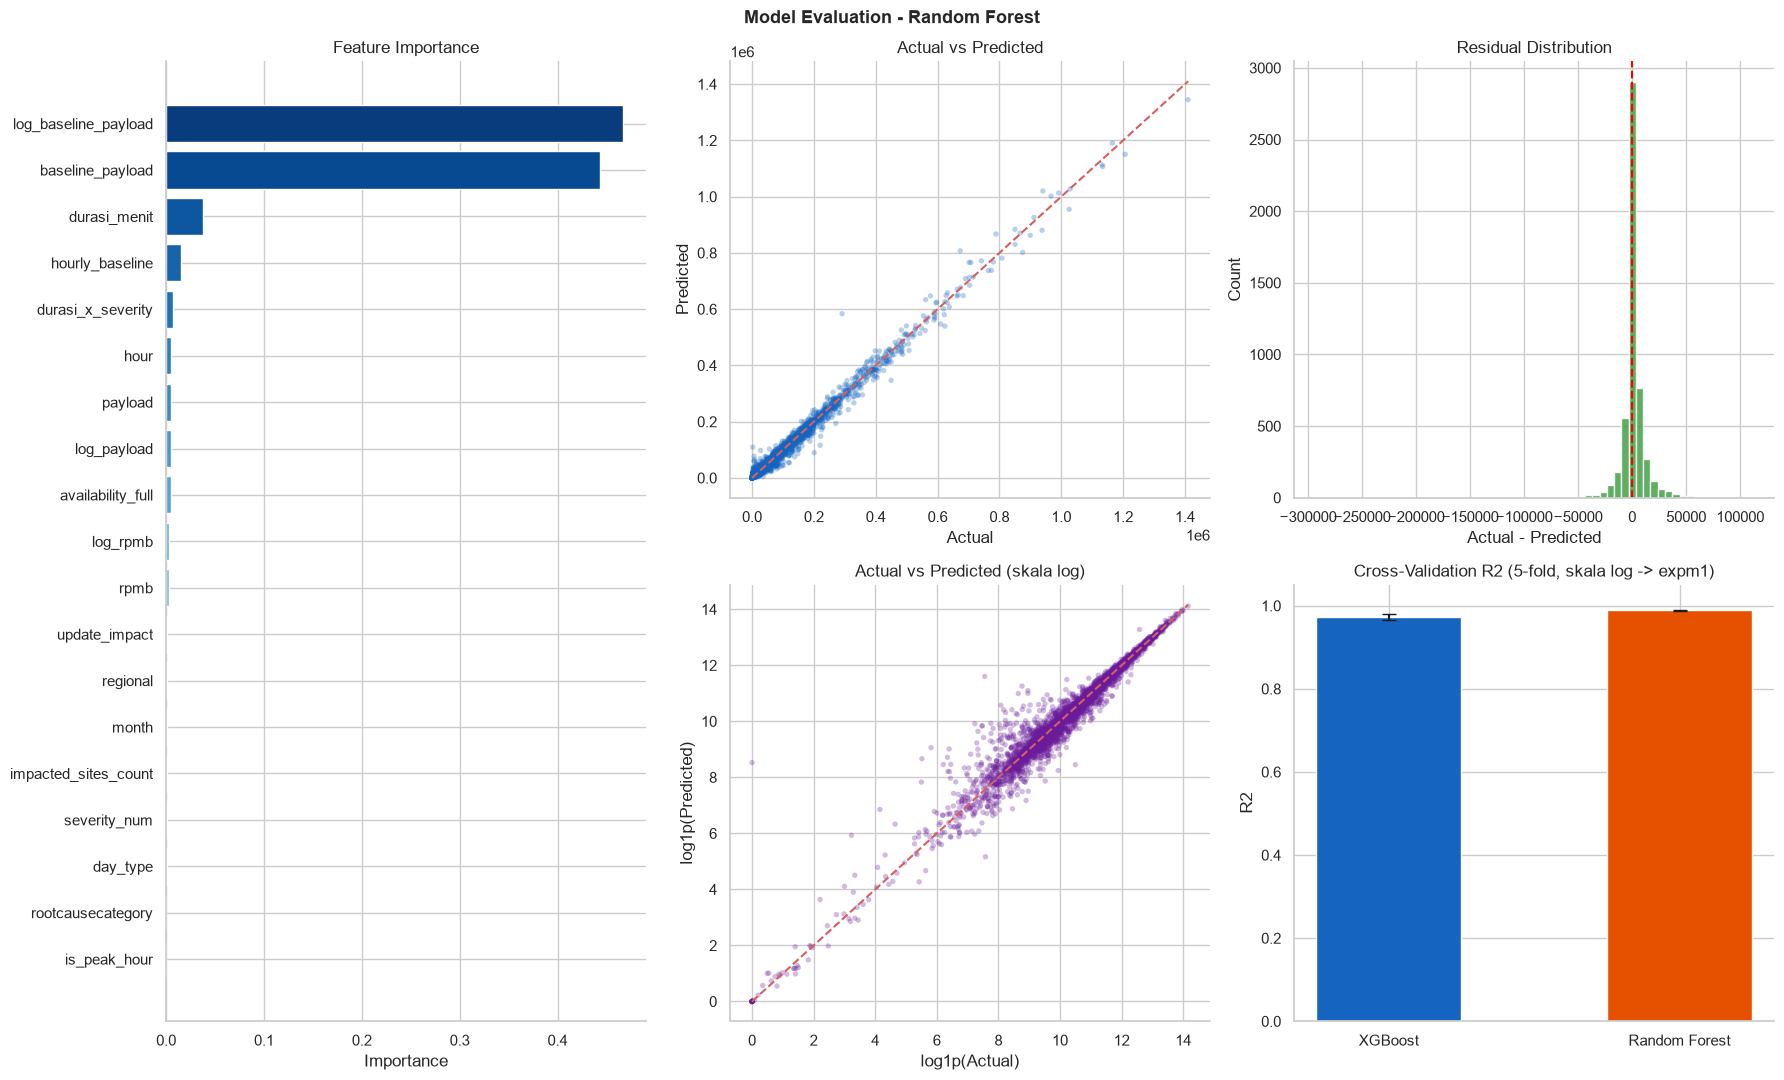

Residual rata-rata (actual - predicted) : 1,265.69
Dashboard evaluasi disimpan di: output_ml_new/evaluation_report.png


In [56]:
fig = plt.figure(figsize=(18, 11))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle(f"Model Evaluation - {best_model_name}", fontsize=13, fontweight="bold")

ax_fi = fig.add_subplot(gs[:, 0])
ax_fi.barh(feat_imp["Feature"], feat_imp["Importance"], color=sns.color_palette("Blues_r", len(feat_imp)))
ax_fi.invert_yaxis()
ax_fi.set_title("Feature Importance")
ax_fi.set_xlabel("Importance")
ax_fi.spines[["top", "right"]].set_visible(False)

ax_avp = fig.add_subplot(gs[0, 1])
ax_avp.scatter(y_test_raw, best_preds, alpha=0.3, s=15, color="#1565C0", edgecolors="none")
lo_val = min(y_test_raw.min(), best_preds.min())
hi_val = max(y_test_raw.max(), best_preds.max())
ax_avp.plot([lo_val, hi_val], [lo_val, hi_val], "r--", linewidth=1.5)
ax_avp.set_title("Actual vs Predicted")
ax_avp.set_xlabel("Actual")
ax_avp.set_ylabel("Predicted")
ax_avp.spines[["top", "right"]].set_visible(False)

ax_res = fig.add_subplot(gs[0, 2])
residuals = y_test_raw.values - best_preds
ax_res.hist(residuals, bins=60, color="#43A047", edgecolor="white", alpha=0.85)
ax_res.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax_res.set_title("Residual Distribution")
ax_res.set_xlabel("Actual - Predicted")
ax_res.set_ylabel("Count")
ax_res.spines[["top", "right"]].set_visible(False)

ax_log = fig.add_subplot(gs[1, 1])
ax_log.scatter(np.log1p(y_test_raw), np.log1p(np.clip(best_preds, 0, None)), alpha=0.3, s=15, color="#6A1B9A", edgecolors="none")
ax_log.plot([0, np.log1p(hi_val)], [0, np.log1p(hi_val)], "r--", linewidth=1.5)
ax_log.set_title("Actual vs Predicted (skala log)")
ax_log.set_xlabel("log1p(Actual)")
ax_log.set_ylabel("log1p(Predicted)")
ax_log.spines[["top", "right"]].set_visible(False)

ax_cv = fig.add_subplot(gs[1, 2])
ax_cv.bar(["XGBoost", "Random Forest"], [xgb_cv.mean(), rf_cv.mean()],
          yerr=[xgb_cv.std(), rf_cv.std()], color=["#1565C0", "#E65100"], capsize=5, width=0.5)
ax_cv.set_ylim(0, 1.05)
ax_cv.set_title("Cross-Validation R2 (5-fold, skala log -> expm1)")
ax_cv.set_ylabel("R2")
ax_cv.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
dashboard_path = f"{OUTPUT_DIR}/evaluation_report.png"
plt.savefig(dashboard_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Residual rata-rata (actual - predicted) : {residuals.mean():,.2f}")
print(f"Dashboard evaluasi disimpan di: {dashboard_path}")

#### 11.5 EXPORT HASIL PREDIKSI TEST SET
Menyimpan seluruh hasil prediksi model terbaik pada test set ke CSV
(lengkap dengan kolom error), lalu menampilkan 10 baris dengan error
absolut terbesar -- berguna untuk investigasi kasus yang paling meleset.

In [57]:
df_predictions = X_test.copy()
df_predictions["actual_loss_payload"] = y_test_raw.values
df_predictions["predicted_loss_payload"] = best_preds
df_predictions["absolute_error"] = np.abs(y_test_raw.values - best_preds)
df_predictions["error_pct"] = (
    df_predictions["absolute_error"] /
    (df_predictions["actual_loss_payload"].abs() + 1e-9) * 100
)
df_predictions = df_predictions.sort_values("absolute_error", ascending=False)
predictions_path = f"{OUTPUT_DIR}/predictions_test_set.csv"
df_predictions.to_csv(predictions_path, index=True)

print(f"Seluruh hasil prediksi test set disimpan di: {predictions_path}")
print("10 prediksi dengan error terbesar:")
print(df_predictions[["actual_loss_payload", "predicted_loss_payload", "absolute_error", "error_pct"]]
      .head(10).round(2).to_string())

Seluruh hasil prediksi test set disimpan di: output_ml_new/predictions_test_set.csv
10 prediksi dengan error terbesar:
       actual_loss_payload  predicted_loss_payload  absolute_error  error_pct
388              290983.49               583640.94       292657.45     100.58
25337            673110.41               807264.85       134154.44      19.93
20933            200830.29                89775.52       111054.77      55.30
18427              1906.31               109522.69       107616.38    5645.28
6888             220236.03               115956.63       104279.40      47.35
6886             449769.25               346963.78       102805.48      22.86
1800             623378.13               539576.99        83801.15      13.44
4772             940431.31              1019910.66        79479.35       8.45
20526            788438.23               867041.60        78603.36       9.97
8592             270763.18               193772.31        76990.87      28.43


### 12. CONTOH INFERENCE PADA INSIDEN BARU
Memprediksi loss_payload untuk SATU insiden baru yang datanya masih
mentah (raw_input), dengan MEREPLIKASI PERSIS seluruh feature
engineering yang dipakai saat training, supaya fitur yang dikirim ke
model konsisten dengan yang dipelajari model

In [58]:
raw_input = {
    "site_id": "SBS087",
    "severity": "Low",
    "alarm_start_time": "2026-04-29 23:57:36",
    "duarasi_alaram": "14:36:59",
    "payload": "0",
    "baseline_payload": "9750,617441",
    "rpmb": "3,259676896",
    "availability_full": "62,53472222",
    "regional": "KALIMANTAN",
    "day_type": "Weekday",
    "rootcausecategory": "Power",
    "update_impact": "1",
    "url": "SBS087",
}
actual = 487.53

row = {}
row["severity_num"] = SEV_MAP.get(str(raw_input["severity"]).lower(), np.nan)
row["durasi_menit"] = duration_to_minutes(raw_input["duarasi_alaram"])
row["baseline_payload"] = float(str(raw_input["baseline_payload"]).replace(",", "."))
row["payload"] = float(str(raw_input["payload"]).replace(",", "."))
row["rpmb"] = float(str(raw_input["rpmb"]).replace(",", "."))
row["availability_full"] = float(str(raw_input["availability_full"]).replace(",", "."))
row["update_impact"] = float(raw_input.get("update_impact", 1))

alarm_start = pd.to_datetime(raw_input["alarm_start_time"], errors="coerce")
row["hour"] = alarm_start.hour
row["month"] = alarm_start.month
row["is_peak_hour"] = int(8 <= alarm_start.hour <= 22)
row["day_type_str"] = raw_input.get("day_type", "Weekday")
row["impacted_sites_count"] = count_impacted_sites(raw_input.get("url", ""))

row["log_baseline_payload"] = np.log1p(row["baseline_payload"])
row["log_payload"] = np.log1p(row["payload"])
row["log_rpmb"] = np.log1p(row["rpmb"])
row["durasi_x_severity"] = row["durasi_menit"] * row["severity_num"]

hb_match = df_hourly[
    (df_hourly["site_id"] == raw_input["site_id"]) &
    (df_hourly["hour"] == row["hour"]) &
    (df_hourly["day_name"].str.lower() == row["day_type_str"].lower())
]["avg_payload_gb"]
row["hourly_baseline"] = hb_match.values[0] if not hb_match.empty else 0

encode_map = {
    "site_id": raw_input["site_id"],
    "regional": raw_input["regional"],
    "day_type": row["day_type_str"],
    "rootcausecategory": raw_input.get("rootcausecategory", "unknown"),
}
for col, value in encode_map.items():
    encoder = encoders[col]
    val_str = str(value)
    if val_str in encoder.classes_:
        row[col] = encoder.transform([val_str])[0]
    else:
        row[col] = encoder.transform(["unknown"])[0] if "unknown" in encoder.classes_ else 0
        print(f"  Peringatan: kategori '{val_str}' pada kolom '{col}' belum pernah "
              f"dilihat saat training -> fallback ke 'unknown'.")

X_new = pd.DataFrame([{f: row.get(f, np.nan) for f in FEATURES_FINAL}])
prediction_raw = best_model.predict(X_new)[0]
final_pred = np.expm1(prediction_raw) if best_is_log_model else prediction_raw
final_pred = round(float(final_pred), 2)

print(f"Predicted loss_payload : {final_pred:,.2f}")
print(f"Actual loss_payload    : {actual:,.2f}")
print(f"Absolute error         : {abs(final_pred - actual):,.2f}")

Predicted loss_payload : 994.25
Actual loss_payload    : 487.53
Absolute error         : 506.72


### 13. REPORTING

#### 13.1 Simpan Model dan Artifacts

In [59]:
model_artifacts = {
    "model": best_model,
    "encoders": encoders,
    "features": FEATURES_FINAL,
    "sev_map": SEV_MAP,
    "is_log_model": best_is_log_model,
}
model_path = f"{OUTPUT_DIR}/best_incident_model.joblib"
joblib.dump(model_artifacts, model_path)

print(f"Model dan artifacts berhasil disimpan di: {model_path}")
print(f"Ukuran file: {os.path.getsize(model_path) / (1024 * 1024):.2f} MB")

Model dan artifacts berhasil disimpan di: output_ml_new/best_incident_model.joblib
Ukuran file: 890.09 MB


#### 13.2 Pipeline Report

In [60]:
report = f"""Network Incident Loss Payload Predictor

DATA
File Utama: {FILE_MAIN}
File Pendukung: {FILE_HOURLY}
Baris total : {len(df_raw)}
Baris valid : {len(df_model)} (setelah buang baris tanpa target dan fitur tidak lengkap)
Jumlah fitur : {len(FEATURES_FINAL)}

TARGET
Transformasi : log1p saat training, expm1 saat prediksi
Outlier : tidak dipotong (nilai ekstrem adalah insiden valid)

MODEL
Train/Test : 80/20
Kedua model (XGBoost & Random Forest) dilatih dan di-CV pada skala log,
lalu prediksi di-expm1 sebelum dievaluasi di skala asli -- perbandingan apple-to-apple.
XGBoost CV R2 : {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})
RF CV R2 : {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})
Best model : {best_model_name}

EVALUASI (skala asli)
{results_df.round(4).to_string()}

TOP-10 FEATURE IMPORTANCE
{feat_imp.head(10).to_string(index=False)}

BEST METRICS
R2 : {best_metrics['R2']:.4f}
MAE : {best_metrics['MAE']:,.2f}
RMSE : {best_metrics['RMSE']:,.2f}
"""
report_path = f"{OUTPUT_DIR}/pipeline_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

metrics_summary_path = f"{OUTPUT_DIR}/metrics_summary.csv"
results_df.round(4).to_csv(metrics_summary_path)

print(f"Laporan disimpan di: {report_path}")
print(f"Ringkasan metrik disimpan di: {metrics_summary_path}")
print(report)

Laporan disimpan di: output_ml_new/pipeline_report.txt
Ringkasan metrik disimpan di: output_ml_new/metrics_summary.csv
Network Incident Loss Payload Predictor

DATA
File Utama: inap_ticketing_incident_loss_payload_2026.xlsx
File Pendukung: baseline_payload_hourly_weekly.csv
Baris total : 81033
Baris valid : 25684 (setelah buang baris tanpa target dan fitur tidak lengkap)
Jumlah fitur : 19

TARGET
Transformasi : log1p saat training, expm1 saat prediksi
Outlier : tidak dipotong (nilai ekstrem adalah insiden valid)

MODEL
Train/Test : 80/20
Kedua model (XGBoost & Random Forest) dilatih dan di-CV pada skala log,
lalu prediksi di-expm1 sebelum dievaluasi di skala asli -- perbandingan apple-to-apple.
XGBoost CV R2 : 0.9729 (+/- 0.0076)
RF CV R2 : 0.9892 (+/- 0.0007)
Best model : Random Forest

EVALUASI (skala asli)
                     MAE        RMSE      R2
XGBoost        7228.3319  14486.3794  0.9839
Random Forest  6128.0809  12133.3204  0.9887

TOP-10 FEATURE IMPORTANCE
             Feat